In [14]:
import os
from PIL import Image

import matplotlib.pyplot as plt

import numpy as np

import torch
from skimage.measure import label, regionprops
from scipy.ndimage import binary_erosion

In [6]:
def load_image_mask_pairs(path, image_prefix="patch", mask_prefix="mask",
                          image_ext=".png", mask_ext=".tiff"):
    """
    Load PNG images and TIFF masks into two lists.
    Expected filenames: image_00.png and mask_00.tiff.
    """
    images = []
    masks = []

    files = os.listdir(path)

    # Dictionaries: index → filename
    image_files = {}
    mask_files = {}

    for f in files:
        # IMAGE FILES
        if f.startswith(image_prefix + "_") and f.endswith(image_ext):
            idx = int(f.split("_")[-1].split(".")[0])
            image_files[idx] = f

        # MASK FILES
        elif f.startswith(mask_prefix + "_") and f.endswith(mask_ext):
            idx = int(f.split("_")[-1].split(".")[0])
            mask_files[idx] = f

    # Load only matching index pairs
    common_indices = sorted(set(image_files.keys()) & set(mask_files.keys()))

    for idx in common_indices:
        img = Image.open(os.path.join(path, image_files[idx]))        # PNG
        mask = Image.open(os.path.join(path, mask_files[idx]))        # TIFF
        images.append(img)
        masks.append(mask)

    return images, masks

In [7]:
path = "/Volumes/CT-Data/DFG_Benni/Probe4_klein/results"


images, masks = load_image_mask_pairs(path)

print(len(images), len(masks))
print(images[0], masks[0])

20 20
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x1152F7990> <PIL.TiffImagePlugin.TiffImageFile image mode=I;16 size=1024x1024 at 0x1148B9610>


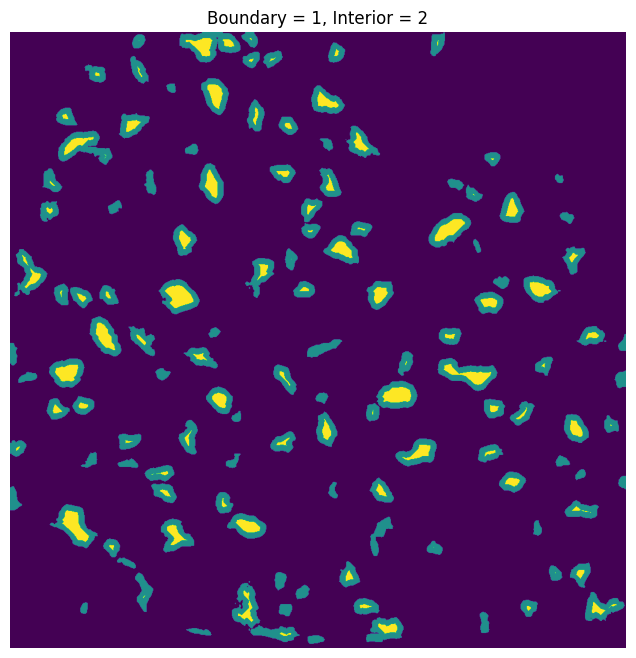

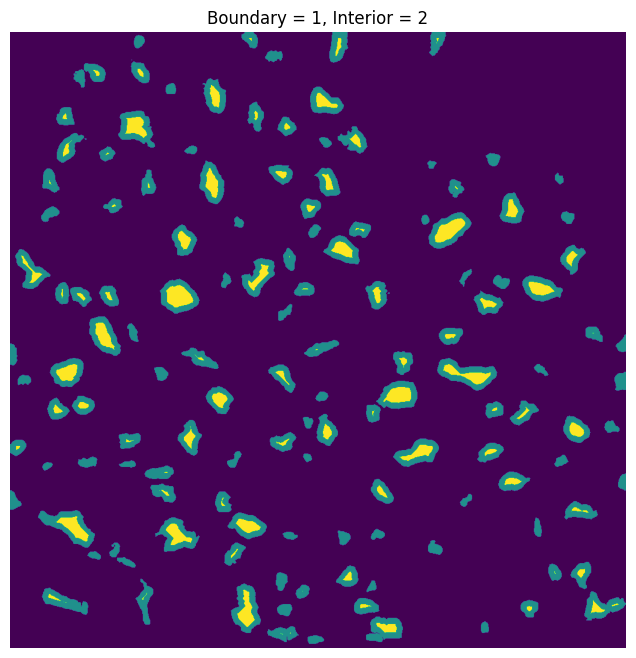

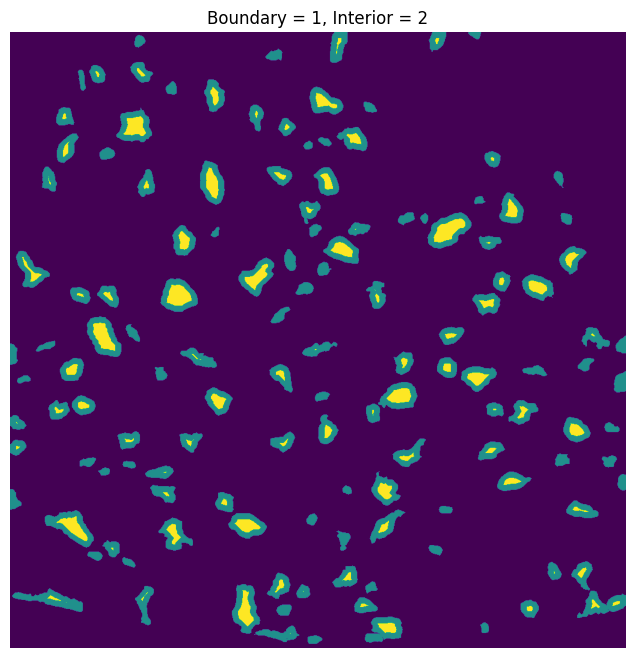

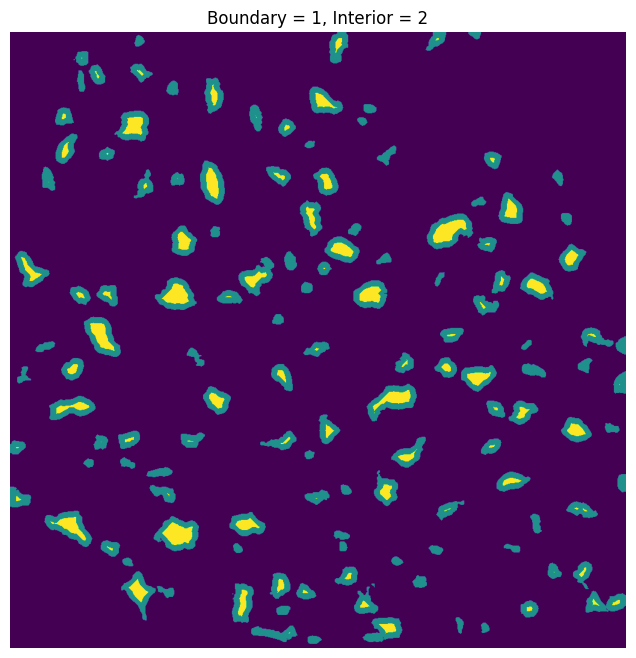

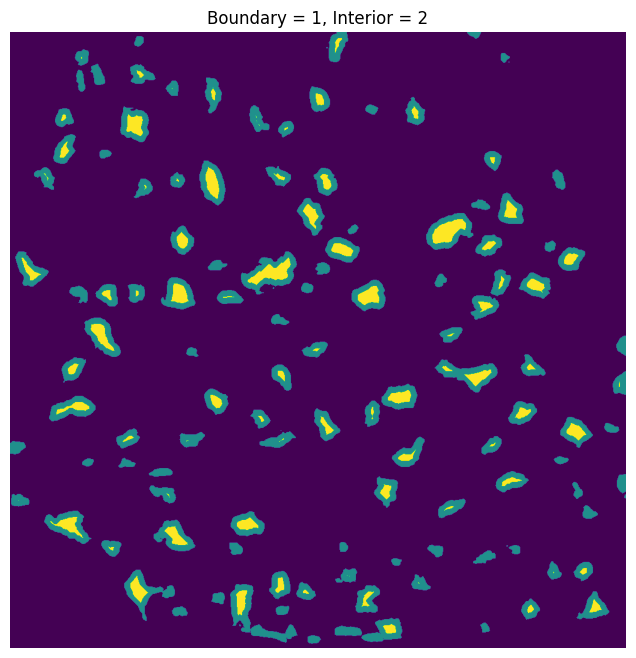

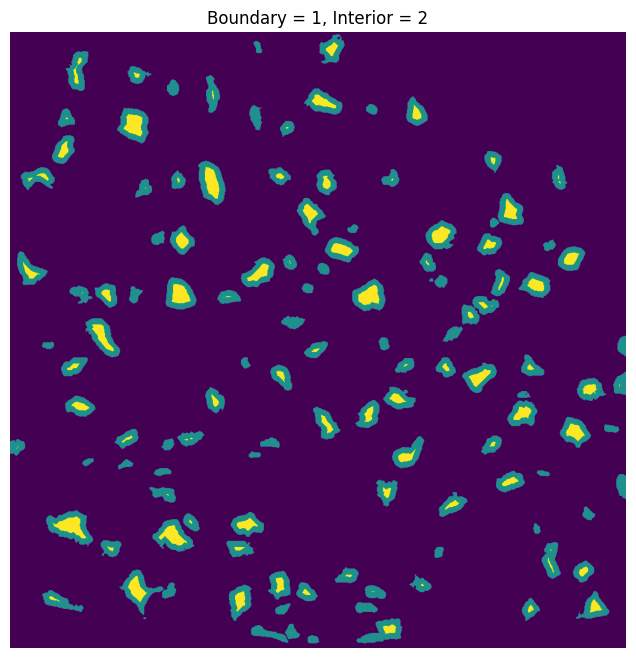

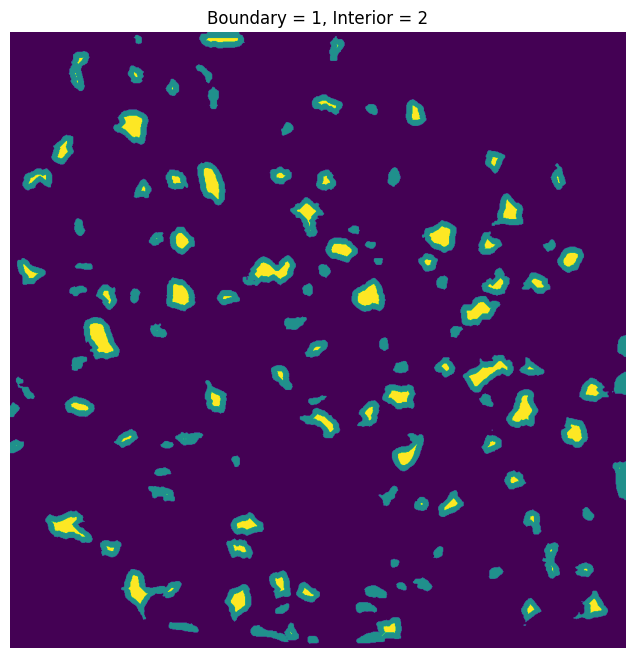

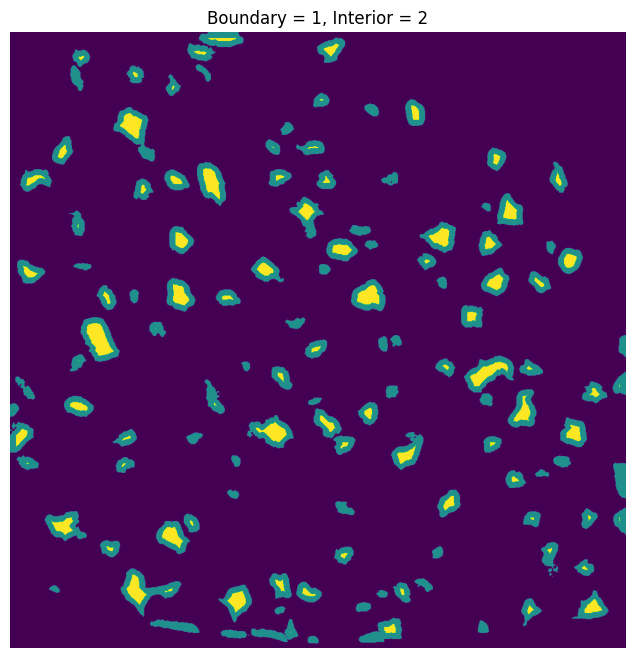

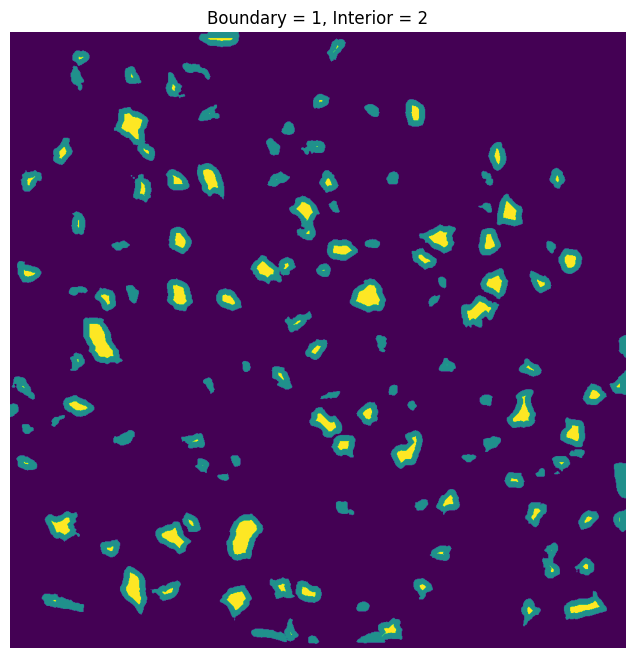

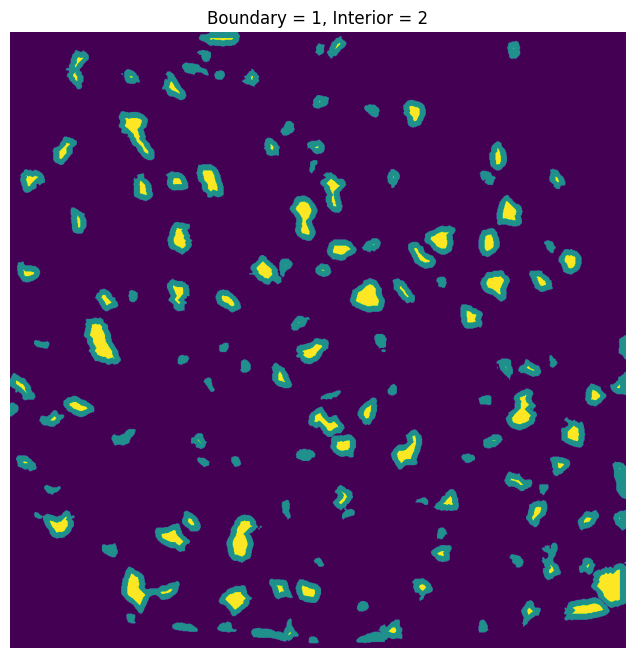

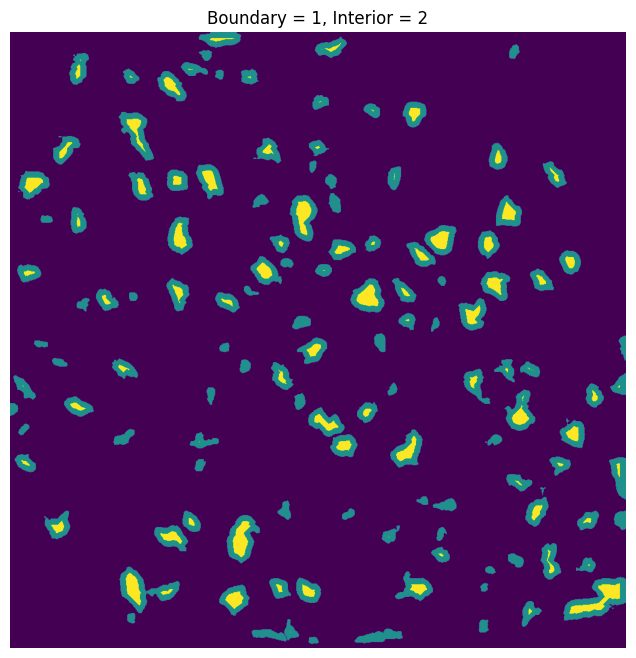

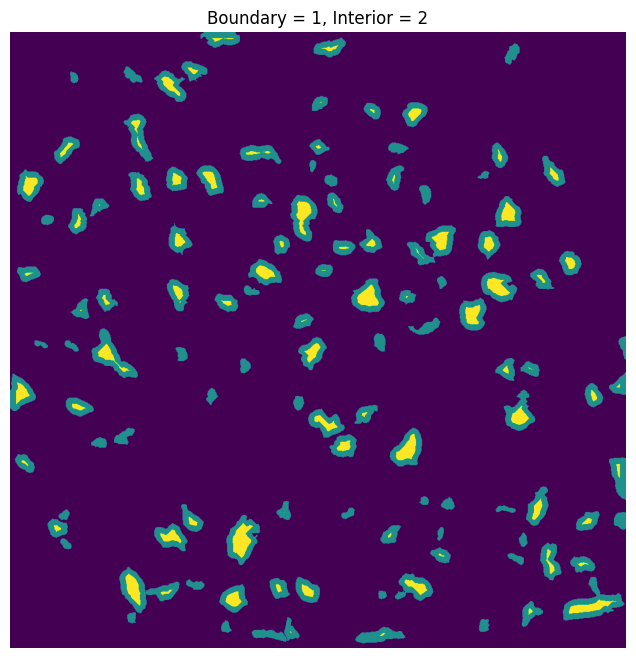

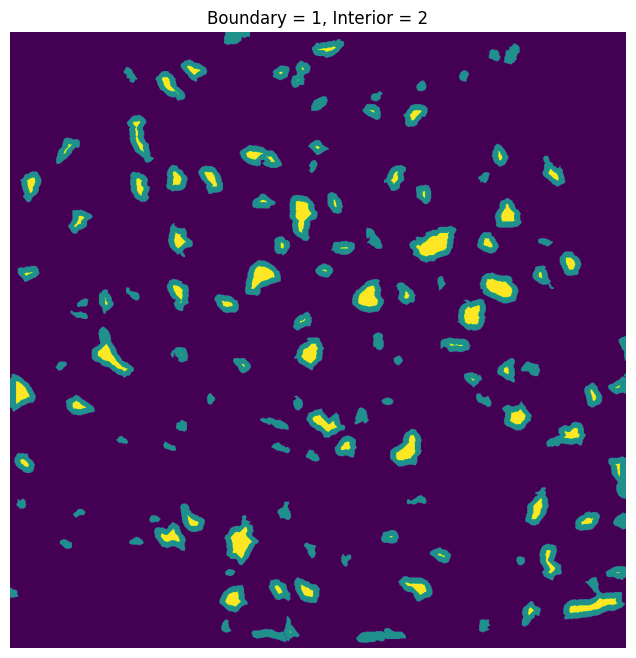

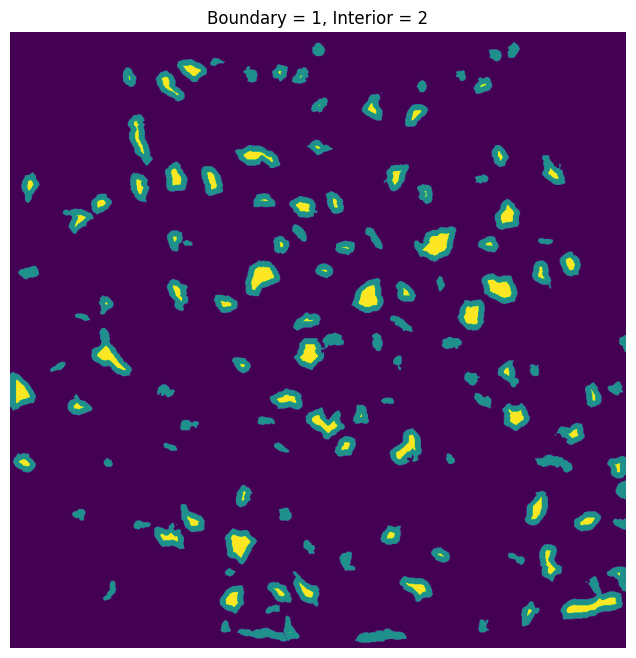

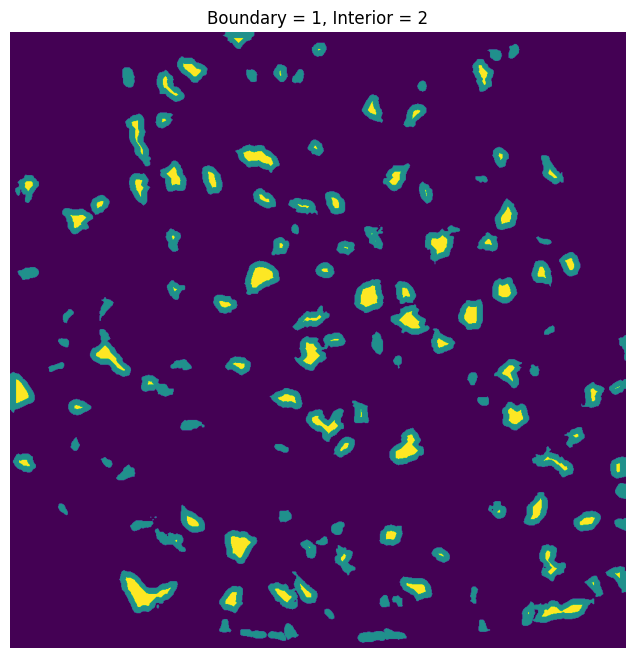

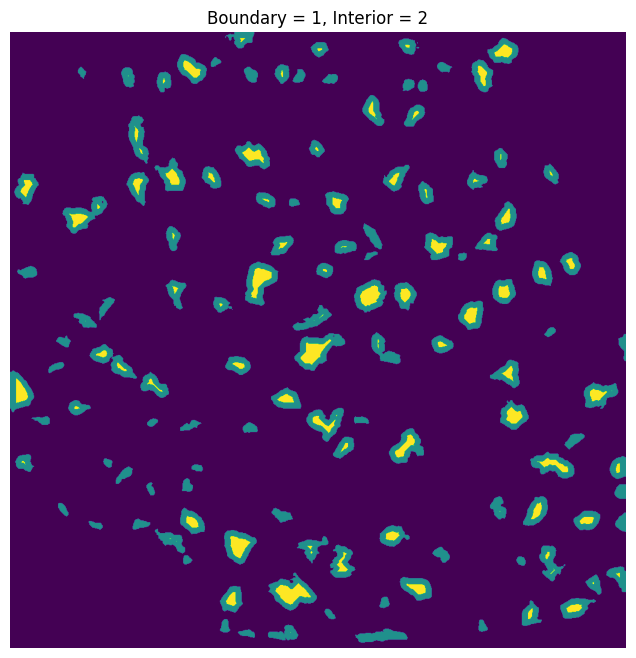

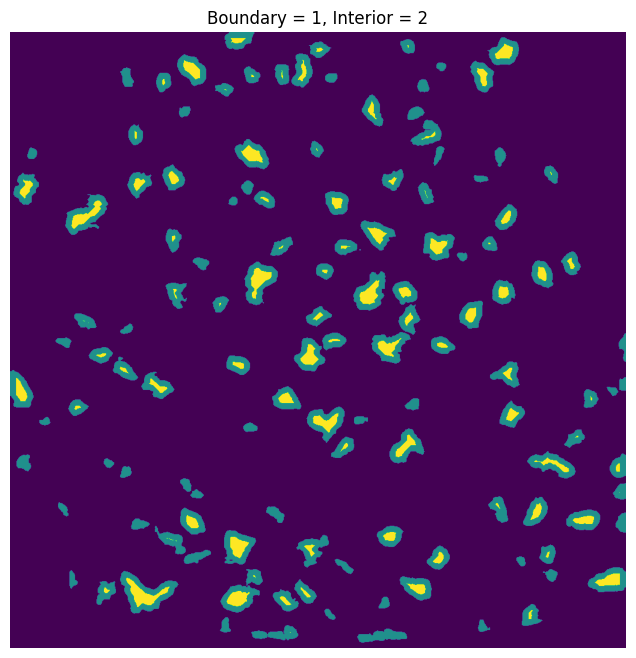

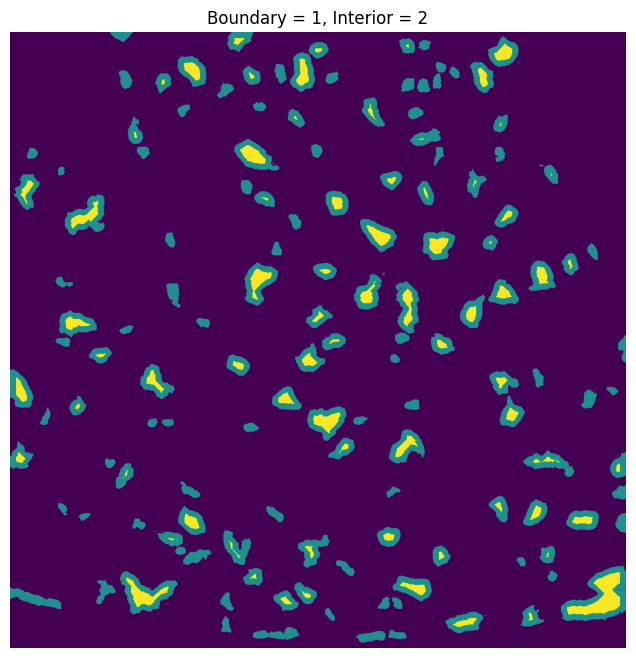

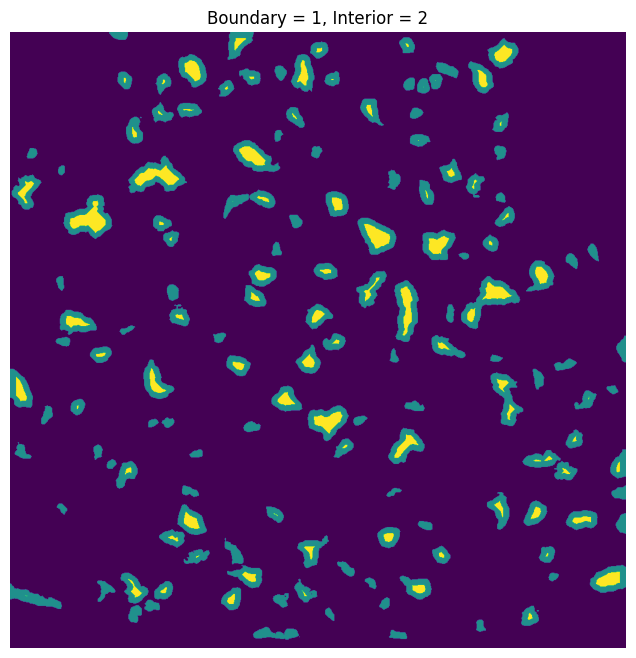

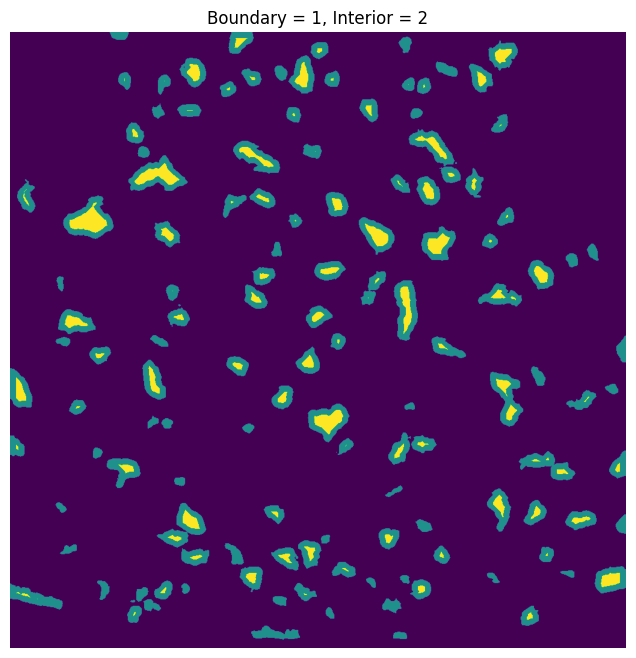

In [21]:
mask = masks[0]


for i, mask in enumerate(masks):

    mask_np = np.array(mask)

    # Label instances
    instances = label(mask_np > 0)

    pad = 10  # boundary thickness (inside)

    # New map:
    # 0 = background
    # 1 = boundary
    # 2 = interior (eroded)
    new_map = np.zeros_like(instances, dtype=np.uint8)

    for inst_id in np.unique(instances):
        if inst_id == 0:
            continue

        inst_mask = (instances == inst_id)

        # eroded inner region
        eroded = binary_erosion(inst_mask, iterations=pad)

        # inner boundary (inside contour)
        boundary = inst_mask & ~eroded

        # fill map:
        new_map[boundary] = 1
        new_map[eroded] = 2

    plt.figure(figsize=(8,8))
    plt.imshow(new_map, cmap="viridis")
    plt.title("Boundary = 1, Interior = 2")
    plt.axis("off")
    plt.show()

    Image.fromarray(new_map.astype(np.uint8)).save(f"mask_boundary_{i:02d}.tiff")
